# 15: Benchmarking, Stability, and Sensitivity

A single causal discovery run is rarely enough. Discovery algorithms make assumptions about independence tests, scores, linearity, noise, hidden variables, sample size, and tuning choices. If a learned graph changes completely when one of those choices changes, the graph should be treated as a fragile hypothesis.

We build a compact benchmarking workflow for `causal-learn`. We will simulate data from a known observed DAG, run several algorithm families, and then stress-test the learned graphs across sample size, noise, tuning settings, nonlinearity, and hidden confounding.

The goal is to learn how to report causal discovery results honestly: what was stable, what changed, and which assumptions each method needed.

Estimated runtime: about 2-5 minutes. Most cells are fast; the repeated benchmark grids do several PC, GES, and DirectLiNGAM fits.


## Learning Goals

By the end, you should be able to:

- design a small benchmark with known graph truth;
- compare constraint-based, score-based, and functional causal discovery methods;
- separate skeleton recovery from edge direction recovery;
- run sample-size, noise, tuning, and seed stability checks;
- recognize when hidden confounding or nonlinear structure breaks an observed-DAG benchmark;
- produce compact benchmark tables and figures suitable for a causal discovery report.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Benchmarking, Stability, And Sensitivity**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment shows a setting where treatment choice is endogenous and identification must come from a source of quasi-random variation. The experiment asks how much the conclusion changes when assumptions are weakened, altered, or attacked by plausible failure modes.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Causal discovery produces an estimated graph $\widehat G$. A compact benchmark compares it with a reference graph $G$ through structural Hamming distance,

$$
\operatorname{SHD}(\widehat G,G)=\text{edge additions}+\text{edge deletions}+\text{edge reversals}.
$$

Stability can be summarized by a bootstrap edge frequency,

$$
\widehat\pi_{ij}=\frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\{i\rightarrow j\in\widehat G_b\}.
$$

The reporting goal is to show which edges are stable, which assumptions matter, and which conclusions remain tentative.



We will work in this order:

1. Set up imports, outputs, algorithms, and graph helpers.
2. Define a reusable six-variable teaching DAG.
3. Simulate baseline data and draw the true graph.
4. Run PC, GES, and DirectLiNGAM on the same baseline data.
5. Compare skeleton and direction metrics.
6. Run sample-size and seed stability checks.
7. Run noise and tuning sensitivity checks.
8. Run stress scenarios: Gaussian noise, nonlinear effects, and hidden confounding.
9. Run a targeted FCI check under hidden confounding.
10. Save reporting guidance.





## Diagnostics and Interpretation

### Benchmarking Philosophy

Causal discovery benchmarking has a subtle trap: a method can look excellent on data generated exactly from its assumptions and weak elsewhere. That does not make the method bad. It means the benchmark must say what assumptions were tested.

We use three representative methods:

- **PC**: constraint-based discovery using conditional independence tests;
- **GES**: score-based search using a decomposable graph score;
- **DirectLiNGAM**: functional causal discovery for linear non-Gaussian models.

We evaluate two graph layers separately. **Skeleton metrics** ask whether the right variables are adjacent, ignoring arrow direction. **Directed metrics** ask whether arrows point the same way as the true DAG. This separation matters because PC and GES often return partially directed equivalence-class graphs, while LiNGAM returns a directed graph.




#### Setup

The code below imports the scientific stack, causal-learn algorithms, and plotting utilities. It also applies the same local BIC-score compatibility wrapper used in earlier lessons, which keeps GES working cleanly in this Python and NumPy environment without editing the installed package on disk.


In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import re
import time
import warnings
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "causal_learn":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "causal_learn" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="Using 'local_score_BIC_from_cov' instead for efficiency")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
import causallearn.search.ScoreBased.GES as ges_module
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.FCMBased.lingam.direct_lingam import DirectLiNGAM
NOTEBOOK_PREFIX = "15"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})
print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")


Project root: repository root
Outputs: notebooks/tutorials/causal_learn/outputs


The setup confirms where the lesson writes files. All generated outputs in this lesson use the `15_` prefix.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Package Versions

Benchmark results are easier to reproduce when package versions are saved alongside the output tables.


In [2]:
import causallearn
import sklearn
version_table = pd.DataFrame(
    [
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "causal-learn", "version": getattr(causallearn, "__version__", "not exposed")},
    ]
)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)


,package,version
0,numpy,2.4.4
1,pandas,3.0.2
2,scikit-learn,1.6.1
3,causal-learn,not exposed


The exact versions are now saved. This matters because graph search and numerical thresholds can shift slightly across library releases.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### GES BIC Compatibility Wrapper

This wrapper keeps the GES BIC score numerically safe when recent NumPy versions return one-element matrix objects. The score formula is unchanged; we only convert a one-element result into a Python scalar.


In [3]:
def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    """
    Safe local BIC score used by GES in this lesson.
    
    Parameters
    ----------
    Data : array-like
        Data matrix passed by causal-learn into the local score function.
    i : int
        Target variable index for the local score calculation.
    PAi : list[int]
        Parent indices proposed for the target variable in the local score.
    parameters : dict
        Score-function parameters supplied by causal-learn.
    
    Returns
    -------
    float
        BIC-style local score for one target variable and candidate parent set.
    """
    cov, n = Data
    lambda_value = 1.0 if parameters is None or parameters.get("lambda_value") is None else parameters.get("lambda_value")
    parent_indices = list(PAi)
    if len(parent_indices) == 0:
        residual_variance = cov[i, i]
    else:
        yX = cov[np.ix_([i], parent_indices)]
        XX = cov[np.ix_(parent_indices, parent_indices)]
        beta = np.linalg.solve(XX, yX.T)
        residual_variance = cov[i, i] - float((yX @ beta).item())
    residual_variance = max(float(residual_variance), 1e-12)
    return float(-(n / 2) * np.log(residual_variance) - (len(parent_indices) + 1) * lambda_value * np.log(n) / 2)
ges_module.local_score_BIC_from_cov = local_score_BIC_from_cov
print("GES BIC score wrapper is active.")


GES BIC score wrapper is active.


The wrapper is active for this lesson session only. It does not modify the installed package files.

For the discovery workflow, this result should be read as evidence about graph recovery under the stated assumptions.
<!-- result-implication-expanded -->




### Define the Benchmark DAG

The benchmark graph has six variables and six directed edges. It is small enough to run many times, but rich enough to include a collider, a chain, and a downstream variable with two parents.


In [4]:
VARIABLES = ["need", "intent", "match", "engagement", "support", "renewal"]
VAR_INDEX = {name: i for i, name in enumerate(VARIABLES)}
TRUE_EDGES = [
    ("need", "match"),
    ("intent", "match"),
    ("match", "engagement"),
    ("engagement", "support"),
    ("engagement", "renewal"),
    ("support", "renewal"),
]
true_edge_table = pd.DataFrame(TRUE_EDGES, columns=["source", "target"])
true_edge_table["edge_type"] = "-->"
true_edge_table["run"] = "truth"
true_edge_table = true_edge_table[["run", "source", "edge_type", "target"]]
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_edges.csv", index=False)
display(true_edge_table)


,run,source,edge_type,target
0,truth,need,-->,match
1,truth,intent,-->,match
2,truth,match,-->,engagement
3,truth,engagement,-->,support
4,truth,engagement,-->,renewal
5,truth,support,-->,renewal


This truth table is used by all benchmark metrics. The same true graph is reused across stress scenarios so we can see when violated assumptions create extra or missing observed relationships.




#### Simulate Data from the DAG

The simulator can generate several regimes from the same graph:

- linear Laplace noise for a baseline that favors DirectLiNGAM;
- linear Gaussian noise for Markov-equivalence-focused methods;
- nonlinear transformations for a simple functional misspecification check;
- hidden common causes that violate causal sufficiency.

The hidden-confounding regime should be read carefully: once a hidden common cause exists, the observed DAG is no longer a complete causal graph.


In [5]:
# Define reusable helpers for the Simulate Data From The DAG section.
def draw_noise(rng, family, scale, n_samples):
    """
    Idea: Generate noise from the requested family so robustness checks can compare data-generating conditions.
    
    Parameters
    ----------
    rng : np.random.Generator
        Random generator that makes the simulation reproducible.
    family : object
        Noise family or model family used for the scenario.
    scale : float
        Scale parameter for noise or plotting.
    n_samples : int
        Number of sampled rows or simulated units.
    
    Returns
    -------
    np.ndarray
        Noise vector drawn from the requested distribution and scale.
    """
    if family == "laplace":
        return rng.laplace(loc=0.0, scale=scale, size=n_samples)
    if family == "gaussian":
        return rng.normal(loc=0.0, scale=scale, size=n_samples)
    if family == "student_t":
        return rng.standard_t(df=4, size=n_samples) * scale / np.sqrt(2)
    raise ValueError(f"Unknown noise family: {family}")
def simulate_benchmark_data(
    n_samples=600,
    seed=RANDOM_SEED,
    noise_family="laplace",
    noise_scale=1.0,
    nonlinear=False,
    hidden_strength=0.0,
):
    """
    Simulate the six-variable benchmark graph.
    
    Parameters
    ----------
    n_samples : int
        Number of observations generated, sampled, or evaluated.
    seed : int
        Random seed for reproducible simulation or resampling.
    noise_family : object
        Noise distribution family used in the benchmark simulation.
    noise_scale : object
        Noise scale used to control signal-to-noise difficulty in the simulation.
    nonlinear : object
        Whether nonlinear mechanisms are included in the simulated graph.
    hidden_strength : object
        Strength of the hidden confounder injected into the simulation.
    
    Returns
    -------
    pd.DataFrame
        Benchmark dataset with known graph structure, noise family, and recovery target.
    """
    rng = np.random.default_rng(seed)
    hidden = draw_noise(rng, noise_family, scale=1.0, n_samples=n_samples)
    need = draw_noise(rng, noise_family, noise_scale, n_samples) + hidden_strength * hidden
    intent = draw_noise(rng, noise_family, noise_scale, n_samples) + hidden_strength * hidden
    if nonlinear:
        match = 0.70 * np.tanh(need) + 0.60 * intent + draw_noise(rng, noise_family, noise_scale, n_samples)
        engagement = 0.75 * np.tanh(match) + draw_noise(rng, noise_family, noise_scale, n_samples)
    else:
        match = 0.70 * need + 0.60 * intent + draw_noise(rng, noise_family, noise_scale, n_samples)
        engagement = 0.75 * match + draw_noise(rng, noise_family, noise_scale, n_samples)
    support = -0.65 * engagement + draw_noise(rng, noise_family, noise_scale, n_samples)
    renewal = 0.65 * engagement - 0.45 * support + draw_noise(rng, noise_family, noise_scale, n_samples) + hidden_strength * hidden
    raw = pd.DataFrame(
        {
            "need": need,
            "intent": intent,
            "match": match,
            "engagement": engagement,
            "support": support,
            "renewal": renewal,
        }
    )
    scaled = pd.DataFrame(StandardScaler().fit_transform(raw), columns=VARIABLES)
    return scaled
baseline_df = simulate_benchmark_data(n_samples=600, seed=RANDOM_SEED, noise_family="laplace")
baseline_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_baseline_linear_laplace.csv", index=False)
display(baseline_df.head())


,need,intent,match,engagement,support,renewal
0,-0.051522,0.054419,0.135313,0.193165,0.428653,-0.282088
1,0.463170,0.028769,0.415003,0.733303,-0.370460,-0.020052
2,1.054700,0.731401,0.225194,0.504820,-0.687442,0.540102
3,0.359936,0.349238,0.593094,1.194669,-0.439526,0.480990
4,1.687358,-2.190891,0.231224,0.628663,-1.310662,1.701560


The baseline data are standardized because PC, GES, and DirectLiNGAM all work more cleanly when variables are on comparable scales.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




### Baseline Data Audit

Before benchmarking algorithms, check the basic shape and correlation structure of the baseline data.


,variable,mean,std,min,max,missing_rate
0,need,0.0,1.001,-4.521,4.407,0.0
1,intent,-0.0,1.001,-4.537,4.370,0.0
2,match,-0.0,1.001,-3.492,3.720,0.0
3,engagement,0.0,1.001,-3.438,3.419,0.0
4,support,-0.0,1.001,-4.207,3.496,0.0
5,renewal,-0.0,1.001,-3.730,3.149,0.0


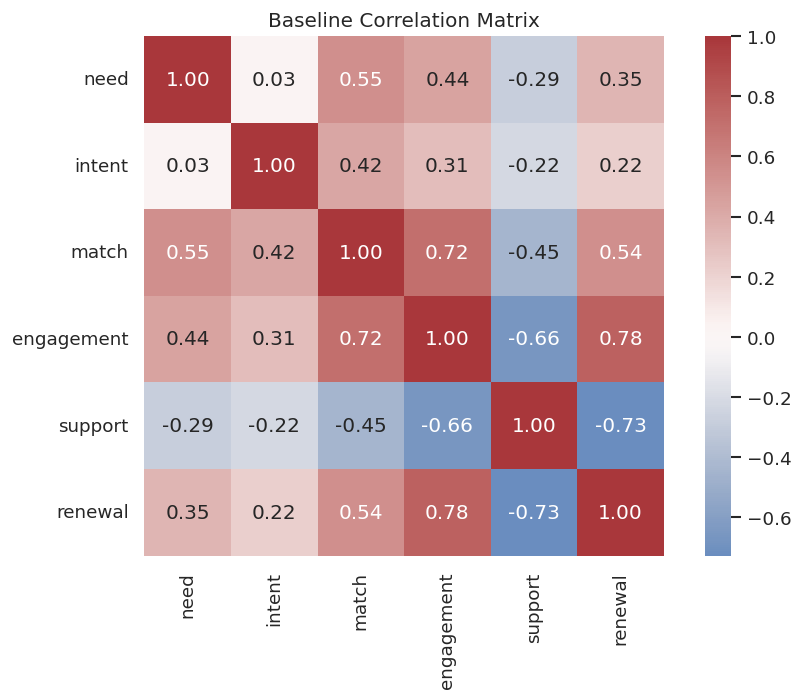

In [6]:
baseline_audit = pd.DataFrame(
    {
        "mean": baseline_df.mean(),
        "std": baseline_df.std(),
        "min": baseline_df.min(),
        "max": baseline_df.max(),
        "missing_rate": baseline_df.isna().mean(),
    }
).reset_index(names="variable")
baseline_corr = baseline_df.corr()
baseline_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_data_audit.csv", index=False)
baseline_corr.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_correlation.csv")
display(baseline_audit.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(baseline_corr, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Baseline Correlation Matrix")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_correlation.png", dpi=160, bbox_inches="tight")
plt.show()


The correlation matrix shows strong relationships along the graph paths, but correlation alone cannot decide which adjacencies are direct or which way arrows point.




#### Draw the True DAG

The figure below is the benchmark target. The same box-and-arrow style is used across the tutorial series to keep graph outputs readable.


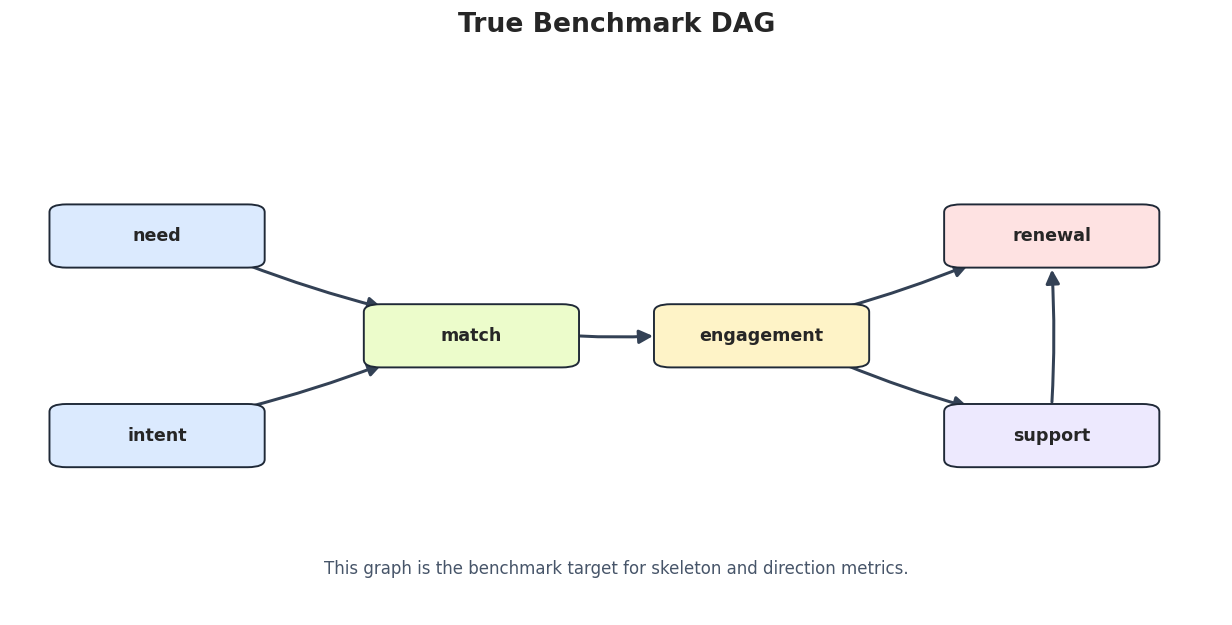

In [7]:
# Define reusable helpers for the Draw The True DAG section.
def trim_edge_to_box(start, end, box_w=0.15, box_h=0.085, gap=0.012):
    """
    Idea: Trim an arrow segment so graph edges stop at the border of each plotted node.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    box_w : object
        Width of the plotted node box.
    box_h : object
        Height of the plotted node box.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Start and end coordinates trimmed so the edge stops at box boundaries.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    distance = (dx**2 + dy**2) ** 0.5
    if distance == 0:
        return start, end
    ux, uy = dx / distance, dy / distance
    candidates = []
    if abs(ux) > 1e-9:
        candidates.append((box_w / 2) / abs(ux))
    if abs(uy) > 1e-9:
        candidates.append((box_h / 2) / abs(uy))
    offset = min(candidates) + gap
    return (x0 + ux * offset, y0 + uy * offset), (x1 - ux * offset, y1 - uy * offset)
def draw_box_graph(edge_df, title, path, note=None):
    """
    Idea: Render a small graph from an edge table using boxed nodes and visible arrows.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    title : str
        Title shown on the resulting plot or report.
    path : str or pathlib.Path
        Input or output path.
    note : object
        Short annotation shown below or beside the plotted figure.
    
    Returns
    -------
    None
        Draws the graph diagram directly on the Matplotlib axes and saves it when requested.
    """
    positions = {
        "need": (0.12, 0.68),
        "intent": (0.12, 0.32),
        "match": (0.38, 0.50),
        "engagement": (0.62, 0.50),
        "support": (0.86, 0.32),
        "renewal": (0.86, 0.68),
    }
    colors = {
        "need": "#dbeafe",
        "intent": "#dbeafe",
        "match": "#ecfccb",
        "engagement": "#fef3c7",
        "support": "#ede9fe",
        "renewal": "#fee2e2",
    }
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    for row in edge_df.itertuples(index=False):
        if row.source not in positions or row.target not in positions:
            continue
        start, end = trim_edge_to_box(positions[row.source], positions[row.target])
        edge_type = row.edge_type
        color = "#334155" if edge_type == "-->" else "#64748b"
        arrowstyle = "-|>" if edge_type == "-->" else "-"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=17,
            linewidth=1.8,
            color=color,
            connectionstyle="arc3,rad=0.03",
            zorder=2,
        )
        ax.add_patch(arrow)
    for variable, (x, y) in positions.items():
        rect = FancyBboxPatch(
            (x - 0.075, y - 0.043),
            0.15,
            0.086,
            boxstyle="round,pad=0.014",
            facecolor=colors[variable],
            edgecolor="#1f2937",
            linewidth=1.15,
            zorder=4,
        )
        ax.add_patch(rect)
        ax.text(x, y, variable, ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=5)
    if note:
        ax.text(0.5, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=16, fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
draw_box_graph(
    true_edge_table,
    "True Benchmark DAG",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_benchmark_dag.png",
    note="This graph is the benchmark target for skeleton and direction metrics.",
)


This DAG is simple, but it contains enough structure to test adjacency recovery, collider handling, and downstream parent selection.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




#### Graph Parsing and Metrics

The next helpers standardize graph outputs from PC, GES, FCI, and DirectLiNGAM. We score two layers:

- skeleton metrics: whether the correct variable pairs are adjacent;
- directed metrics: whether directed arrows match the true direction.

Partially directed or undirected edges count for skeleton recovery but not for directed recovery.


In [8]:
# Define reusable helpers for the Graph Parsing And Metrics section.
def parse_causallearn_edge(edge):
    """
    Idea: Convert a causal-learn graph edge object into plain endpoint labels for tabular auditing.
    
    Parameters
    ----------
    edge : object
        Single graph edge being parsed, drawn, or evaluated.
    
    Returns
    -------
    tuple[str, str, str]
        Source node, endpoint mark, and target node parsed from a causal-learn edge.
    """
    text = str(edge).strip()
    edge_tokens = [" --> ", " <-- ", " <-> ", " o-> ", " <-o ", " o-o ", " --- "]
    for token in edge_tokens:
        if token in text:
            left, right = text.split(token)
            if token == " <-- ":
                return {"source": right.strip(), "edge_type": "-->", "target": left.strip()}
            if token == " <-o ":
                return {"source": right.strip(), "edge_type": "o->", "target": left.strip()}
            return {"source": left.strip(), "edge_type": token.strip(), "target": right.strip()}
    raise ValueError(f"Could not parse edge: {text}")
def graph_to_edge_table(graph, label):
    """
    Idea: Convert a causal-learn graph object into a DataFrame of edge endpoints and method labels.
    
    Parameters
    ----------
    graph : object
        Graph object returned by the causal discovery or causal modeling library.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_table = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    edge_table.insert(0, "run", label)
    return edge_table
def lingam_to_edge_table(adjacency_matrix, label, threshold=0.12):
    """
    Idea: Convert a LiNGAM adjacency matrix into a directed edge table using a coefficient threshold.
    
    Parameters
    ----------
    adjacency_matrix : np.ndarray
        Matrix whose nonzero entries represent candidate directed edges.
    label : str
        Short label attached to a scenario, method, or plotted result.
    threshold : float
        Cutoff used to decide whether a signal or edge is retained.
    
    Returns
    -------
    pd.DataFrame
        Directed edge table from LiNGAM coefficients above the threshold.
    """
    rows = []
    for target in VARIABLES:
        for source in VARIABLES:
            if source == target:
                continue
            coefficient = float(adjacency_matrix[VAR_INDEX[target], VAR_INDEX[source]])
            if abs(coefficient) >= threshold:
                rows.append(
                    {
                        "run": label,
                        "source": source,
                        "edge_type": "-->",
                        "target": target,
                        "coefficient": coefficient,
                        "abs_coefficient": abs(coefficient),
                    }
                )
    return pd.DataFrame(rows, columns=["run", "source", "edge_type", "target", "coefficient", "abs_coefficient"])
def skeleton_pairs(edge_df):
    """
    Idea: Reduce an edge table to unordered node pairs so skeleton recovery can be evaluated.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    set[tuple[str, str]]
        Unordered node pairs representing the learned graph skeleton.
    """
    if edge_df.empty:
        return set()
    return {tuple(sorted((row.source, row.target))) for row in edge_df.itertuples(index=False)}
def directed_pairs(edge_df):
    """
    Idea: Extract directed edge pairs from an edge table so orientation recovery can be evaluated.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    set[tuple[str, str]]
        Ordered source-target pairs representing directed learned edges.
    """
    if edge_df.empty:
        return set()
    return {(row.source, row.target) for row in edge_df.itertuples(index=False) if row.edge_type == "-->"}
TRUE_DIRECTED = set(TRUE_EDGES)
TRUE_SKELETON = {tuple(sorted(edge)) for edge in TRUE_EDGES}
def summarize_against_truth(edge_df, label, scenario="baseline"):
    """
    Idea: Summarize the against truth into a compact table for interpretation in the Graph Parsing And Metrics section.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    label : str
        Short label attached to a scenario, method, or plotted result.
    scenario : str
        Scenario label describing the data-generating or diagnostic condition.
    
    Returns
    -------
    pd.DataFrame
        Graph-recovery summary table with edge counts, precision, recall, missing edges, and extra edges.
    """
    learned_skeleton = skeleton_pairs(edge_df)
    learned_directed = directed_pairs(edge_df)
    skeleton_tp = learned_skeleton & TRUE_SKELETON
    skeleton_fp = learned_skeleton - TRUE_SKELETON
    skeleton_fn = TRUE_SKELETON - learned_skeleton
    directed_tp = learned_directed & TRUE_DIRECTED
    directed_fp = learned_directed - TRUE_DIRECTED
    directed_fn = TRUE_DIRECTED - learned_directed
    reversed_true_edges = {(target, source) for source, target in learned_directed} & TRUE_DIRECTED
    skeleton_precision = len(skeleton_tp) / len(learned_skeleton) if learned_skeleton else np.nan
    skeleton_recall = len(skeleton_tp) / len(TRUE_SKELETON)
    skeleton_f1 = 2 * skeleton_precision * skeleton_recall / (skeleton_precision + skeleton_recall) if skeleton_precision + skeleton_recall > 0 else np.nan
    directed_precision = len(directed_tp) / len(learned_directed) if learned_directed else np.nan
    directed_recall = len(directed_tp) / len(TRUE_DIRECTED)
    directed_f1 = 2 * directed_precision * directed_recall / (directed_precision + directed_recall) if directed_precision + directed_recall > 0 else np.nan
    return pd.DataFrame(
        [
            {
                "scenario": scenario,
                "method": label,
                "reported_edges": len(edge_df),
                "skeleton_precision": skeleton_precision,
                "skeleton_recall": skeleton_recall,
                "skeleton_f1": skeleton_f1,
                "directed_precision": directed_precision,
                "directed_recall": directed_recall,
                "directed_f1": directed_f1,
                "extra_adjacencies": len(skeleton_fp),
                "missed_adjacencies": len(skeleton_fn),
                "reversed_true_edges": len(reversed_true_edges),
                "extra_adjacency_list": " | ".join(f"{a}--{b}" for a, b in sorted(skeleton_fp)),
                "missed_adjacency_list": " | ".join(f"{a}--{b}" for a, b in sorted(skeleton_fn)),
            }
        ]
    )


The metric functions make the benchmark transparent. A partially directed PC or GES graph can still score well on skeleton recovery while receiving lower directed recall.




#### Algorithm Runners

The code below wraps PC, GES, FCI, and DirectLiNGAM so later benchmark grids can call them consistently. We keep the defaults conservative and expose the main tuning knobs.


In [9]:
# Define reusable helpers for the Algorithm Runners section.
def run_pc(data_df, alpha=0.01, label="PC_FisherZ"):
    """
    Idea: Run the PC algorithm for a selected dataset and return recovered edges or diagnostics.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame or tuple
        PC recovery output for the requested dataset and alpha setting.
    """
    start = time.perf_counter()
    result = pc(
        data_df.to_numpy(),
        alpha=alpha,
        indep_test="fisherz",
        stable=True,
        show_progress=False,
        node_names=VARIABLES,
    )
    elapsed = time.perf_counter() - start
    return graph_to_edge_table(result.G, label), elapsed
def run_ges(data_df, lambda_value=1.0, label="GES_BIC"):
    """
    Idea: Run GES under the requested score or penalty setting and return recovered graph information.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    lambda_value : float
        Penalty value used by score-based search or a learner.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame or tuple
        GES recovery output for the requested dataset and penalty setting.
    """
    start = time.perf_counter()
    record = ges(
        data_df.to_numpy(),
        score_func="local_score_BIC_from_cov",
        node_names=VARIABLES,
        parameters={"lambda_value": lambda_value},
    )
    elapsed = time.perf_counter() - start
    return graph_to_edge_table(record["G"], label), elapsed
def run_direct_lingam(data_df, threshold=0.12, label="DirectLiNGAM"):
    """
    Idea: Run DirectLiNGAM and convert the learned adjacency matrix into an edge table.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    threshold : float
        Cutoff used to decide whether a signal or edge is retained.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Directed edge table recovered by DirectLiNGAM.
    """
    start = time.perf_counter()
    model = DirectLiNGAM(random_state=RANDOM_SEED)
    model.fit(data_df.to_numpy())
    elapsed = time.perf_counter() - start
    edge_table = lingam_to_edge_table(model.adjacency_matrix_, label=label, threshold=threshold)
    return edge_table, elapsed, model
def run_fci(data_df, alpha=0.01, label="FCI_FisherZ"):
    """
    Idea: Run the FCI algorithm for a selected dataset and return recovered edges or diagnostics.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame or tuple
        FCI recovery output for the requested dataset and alpha setting.
    """
    start = time.perf_counter()
    graph, _ = fci(
        data_df.to_numpy(),
        independence_test_method="fisherz",
        alpha=alpha,
        show_progress=False,
        node_names=VARIABLES,
    )
    elapsed = time.perf_counter() - start
    return graph_to_edge_table(graph, label), elapsed
def run_benchmark_methods(data_df, scenario="baseline", pc_alpha=0.01, ges_lambda=1.0, lingam_threshold=0.12):
    """
    Idea: Run the chosen discovery methods on a benchmark dataset and collect comparable recovery metrics.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    scenario : str
        Scenario label describing the data-generating or diagnostic condition.
    pc_alpha : object
        Context-specific input used for PC alpha in this helper.
    ges_lambda : object
        Context-specific input used for GES lambda in this helper.
    lingam_threshold : object
        Context-specific input used for LiNGAM threshold in this helper.
    
    Returns
    -------
    pd.DataFrame
        Benchmark table collecting graph-recovery metrics across methods.
    """
    rows = []
    edges = []
    pc_edges, pc_elapsed = run_pc(data_df, alpha=pc_alpha, label="PC_FisherZ")
    rows.append(summarize_against_truth(pc_edges, "PC_FisherZ", scenario).assign(elapsed_seconds=pc_elapsed))
    edges.append(pc_edges.assign(scenario=scenario, elapsed_seconds=pc_elapsed))
    ges_edges, ges_elapsed = run_ges(data_df, lambda_value=ges_lambda, label="GES_BIC")
    rows.append(summarize_against_truth(ges_edges, "GES_BIC", scenario).assign(elapsed_seconds=ges_elapsed))
    edges.append(ges_edges.assign(scenario=scenario, elapsed_seconds=ges_elapsed))
    lingam_edges, lingam_elapsed, _ = run_direct_lingam(data_df, threshold=lingam_threshold, label="DirectLiNGAM")
    rows.append(summarize_against_truth(lingam_edges, "DirectLiNGAM", scenario).assign(elapsed_seconds=lingam_elapsed))
    edges.append(lingam_edges.assign(scenario=scenario, elapsed_seconds=lingam_elapsed))
    return pd.concat(rows, ignore_index=True), pd.concat(edges, ignore_index=True)


These wrappers are small. They avoid hidden defaults in the benchmark loops and make each algorithm's tuning parameters visible.




#### Baseline Algorithm Comparison

Now we run PC, GES, and DirectLiNGAM on the same baseline data. This is the cleanest comparison because the data are linear, acyclic, causally sufficient, and non-Gaussian.


In [10]:
baseline_metrics, baseline_edges = run_benchmark_methods(baseline_df, scenario="linear_laplace_baseline")
baseline_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_method_metrics.csv", index=False)
baseline_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_method_edges.csv", index=False)
display(baseline_metrics.round(4))
display(baseline_edges)


,scenario,method,reported_edges,skeleton_precision,skeleton_recall,skeleton_f1,directed_precision,directed_recall,directed_f1,extra_adjacencies,missed_adjacencies,reversed_true_edges,extra_adjacency_list,missed_adjacency_list,elapsed_seconds
0,linear_laplace_baseline,PC_FisherZ,6,1.0,1.0,1.0,1.0,0.8333,0.9091,0,0,0,,,0.0095
1,linear_laplace_baseline,GES_BIC,6,1.0,1.0,1.0,1.0,0.8333,0.9091,0,0,0,,,0.0133
2,linear_laplace_baseline,DirectLiNGAM,6,1.0,1.0,1.0,1.0,1.0000,1.0000,0,0,0,,,0.0250


,run,source,edge_type,target,scenario,elapsed_seconds,coefficient,abs_coefficient
0,PC_FisherZ,need,-->,match,linear_laplace_baseline,0.009549,NaN,NaN
1,PC_FisherZ,intent,-->,match,linear_laplace_baseline,0.009549,NaN,NaN
2,PC_FisherZ,match,-->,engagement,linear_laplace_baseline,0.009549,NaN,NaN
3,PC_FisherZ,engagement,-->,support,linear_laplace_baseline,0.009549,NaN,NaN
4,PC_FisherZ,engagement,-->,renewal,linear_laplace_baseline,0.009549,NaN,NaN
5,PC_FisherZ,support,---,renewal,linear_laplace_baseline,0.009549,NaN,NaN
6,GES_BIC,need,-->,match,linear_laplace_baseline,0.013260,NaN,NaN
7,GES_BIC,intent,-->,match,linear_laplace_baseline,0.013260,NaN,NaN
8,GES_BIC,match,-->,engagement,linear_laplace_baseline,0.013260,NaN,NaN
9,GES_BIC,engagement,-->,support,linear_laplace_baseline,0.013260,NaN,NaN


The baseline is deliberately friendly to all three methods. PC and GES usually recover the correct skeleton and many directions; DirectLiNGAM can recover all directions because the data match its linear non-Gaussian assumptions.


#### Plot Baseline Metrics

A compact metric plot lets us see the skeleton-versus-direction distinction immediately.


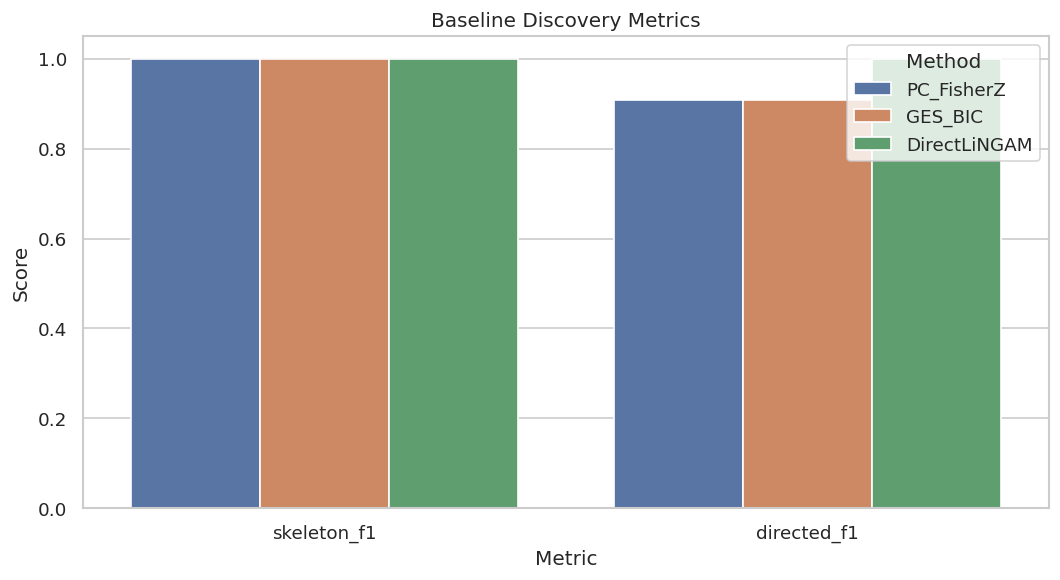

In [11]:
baseline_plot = baseline_metrics.melt(
    id_vars="method",
    value_vars=["skeleton_f1", "directed_f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=baseline_plot, x="metric", y="score", hue="method", ax=ax)
ax.set_title("Baseline Discovery Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Method")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_method_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


The plot shows why benchmark reports should use more than one number. Recovering adjacencies and orienting arrows are related but different tasks.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->




#### Draw Baseline Learned Graphs

The next step saves one graph image per method. Undirected or partially oriented edges are drawn as plain lines so they are not mistaken for confirmed arrow directions.


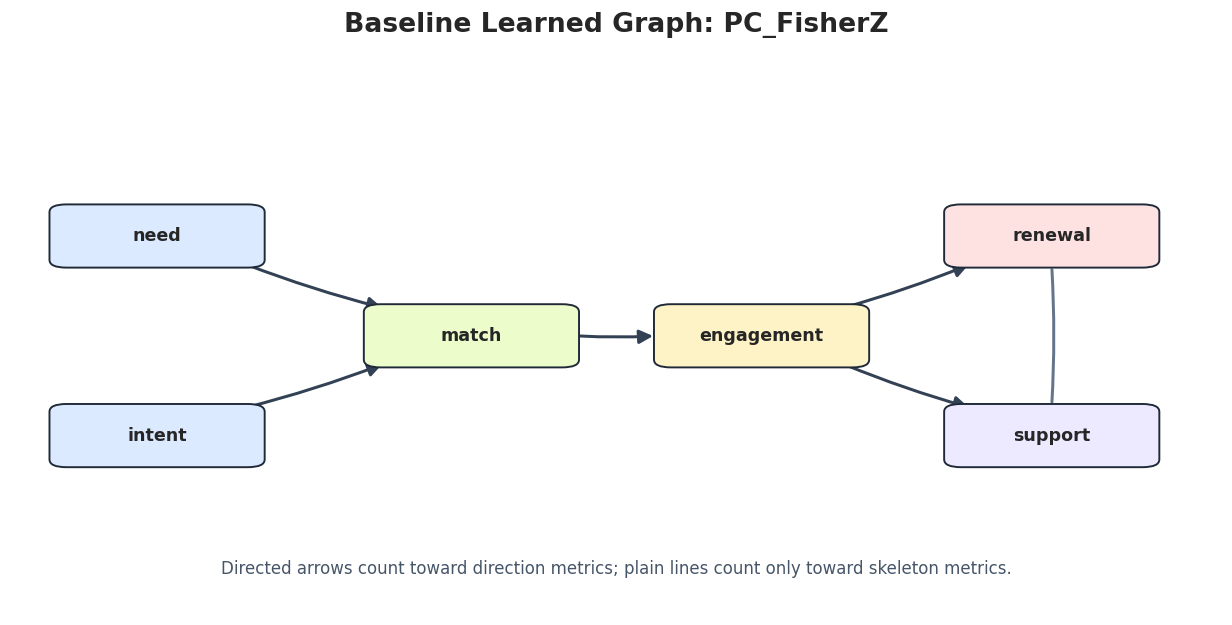

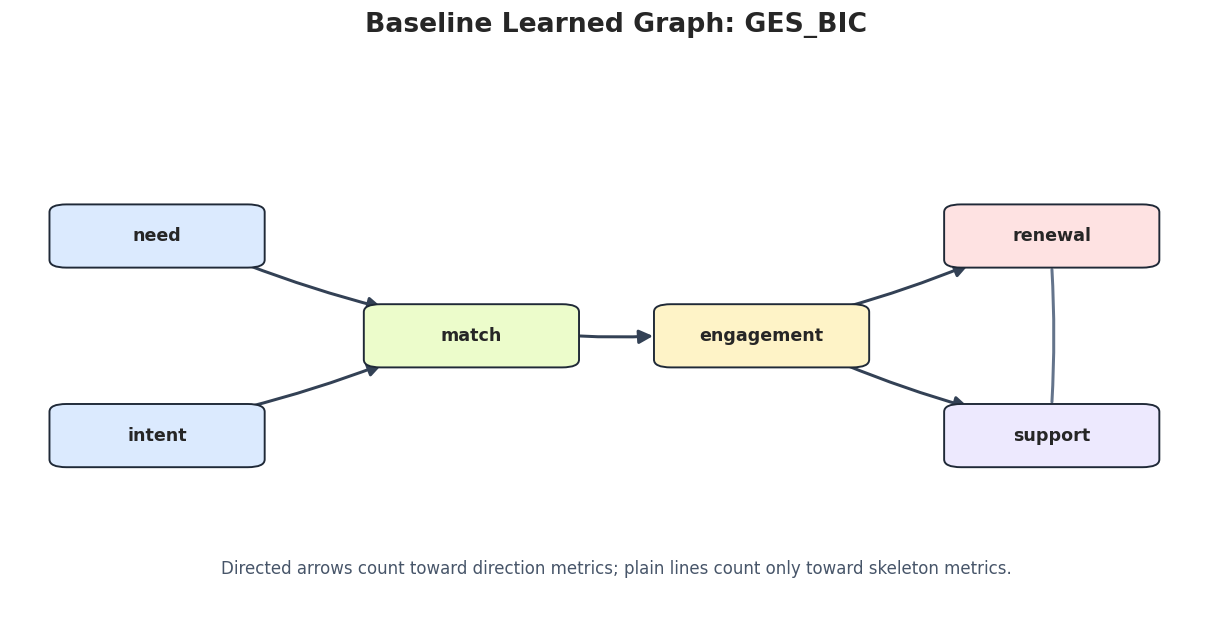

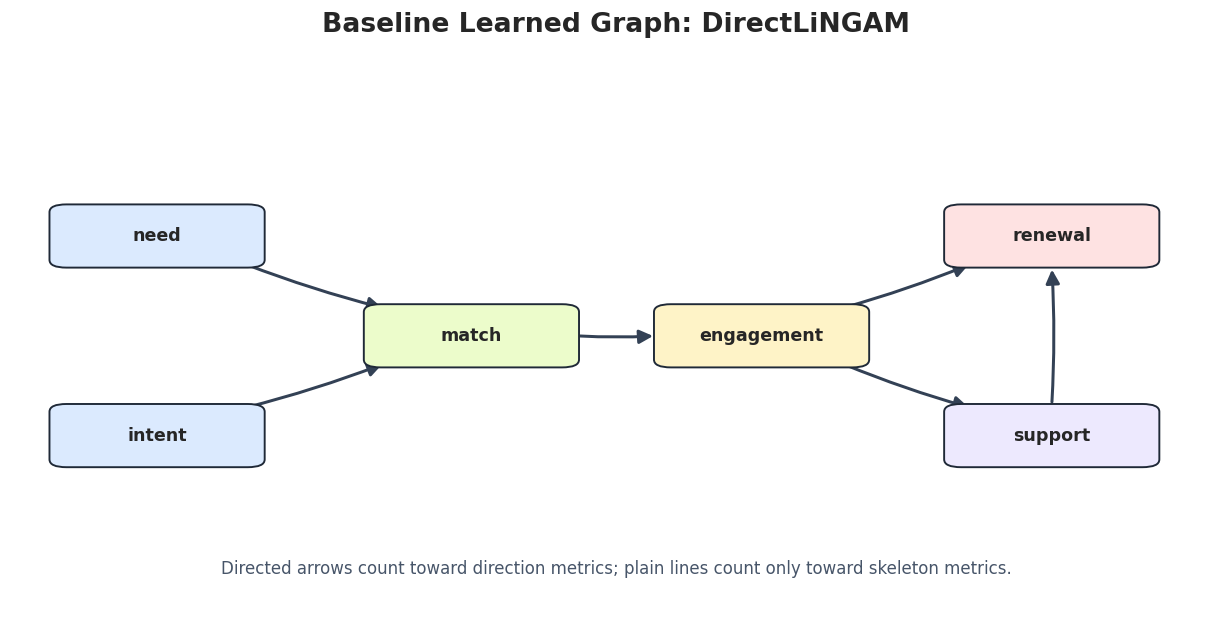

In [12]:
for method_name in baseline_edges["run"].unique():
    method_edges = baseline_edges[baseline_edges["run"] == method_name].copy()
    draw_box_graph(
        method_edges,
        f"Baseline Learned Graph: {method_name}",
        FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_{method_name.lower()}_graph.png",
        note="Directed arrows count toward direction metrics; plain lines count only toward skeleton metrics.",
    )


These plots are useful for qualitative review. The metric table tells us what changed; the graph drawings make the change easier to inspect.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




#### Sample-Size and Seed Stability

A stable discovery method should not depend on one lucky sample. This grid varies sample size and random seed, then reruns all three benchmark methods.


In [13]:
stability_metric_rows = []
stability_edge_rows = []
for n_samples in [150, 300, 600, 1_000]:
    for seed in range(3):
        sample_df = simulate_benchmark_data(n_samples=n_samples, seed=seed, noise_family="laplace")
        metrics, edges = run_benchmark_methods(sample_df, scenario=f"n_{n_samples}_seed_{seed}")
        metrics["n_samples"] = n_samples
        metrics["seed"] = seed
        edges["n_samples"] = n_samples
        edges["seed"] = seed
        stability_metric_rows.append(metrics)
        stability_edge_rows.append(edges)
sample_seed_metrics = pd.concat(stability_metric_rows, ignore_index=True)
sample_seed_edges = pd.concat(stability_edge_rows, ignore_index=True)
sample_seed_summary = sample_seed_metrics.groupby(["method", "n_samples"], as_index=False).agg(
    runs=("seed", "count"),
    mean_skeleton_f1=("skeleton_f1", "mean"),
    min_skeleton_f1=("skeleton_f1", "min"),
    mean_directed_f1=("directed_f1", "mean"),
    min_directed_f1=("directed_f1", "min"),
    mean_elapsed_seconds=("elapsed_seconds", "mean"),
)
sample_seed_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_seed_metrics.csv", index=False)
sample_seed_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_seed_edges.csv", index=False)
sample_seed_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_seed_summary.csv", index=False)
display(sample_seed_summary.round(4))


,method,n_samples,runs,mean_skeleton_f1,min_skeleton_f1,mean_directed_f1,min_directed_f1,mean_elapsed_seconds
0,DirectLiNGAM,150,3,1.0000,1.0000,1.0000,1.0000,0.0210
1,DirectLiNGAM,300,3,1.0000,1.0000,1.0000,1.0000,0.0212
2,DirectLiNGAM,600,3,1.0000,1.0000,1.0000,1.0000,0.0233
3,DirectLiNGAM,1000,3,1.0000,1.0000,1.0000,1.0000,0.0248
4,GES_BIC,150,3,1.0000,1.0000,0.9091,0.9091,0.0131
5,GES_BIC,300,3,1.0000,1.0000,0.9091,0.9091,0.0137
6,GES_BIC,600,3,1.0000,1.0000,0.9091,0.9091,0.0131
7,GES_BIC,1000,3,0.9744,0.9231,0.9138,0.9091,0.0134
8,PC_FisherZ,150,3,0.9697,0.9091,0.8485,0.7273,0.0111
9,PC_FisherZ,300,3,1.0000,1.0000,0.9091,0.9091,0.0076


The summary shows how recovery improves as the sample grows. Small samples can preserve the rough skeleton while making directions less reliable.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Plot Sample-Size Stability

The line plot uses the mean F1 scores across seeds for each sample size.


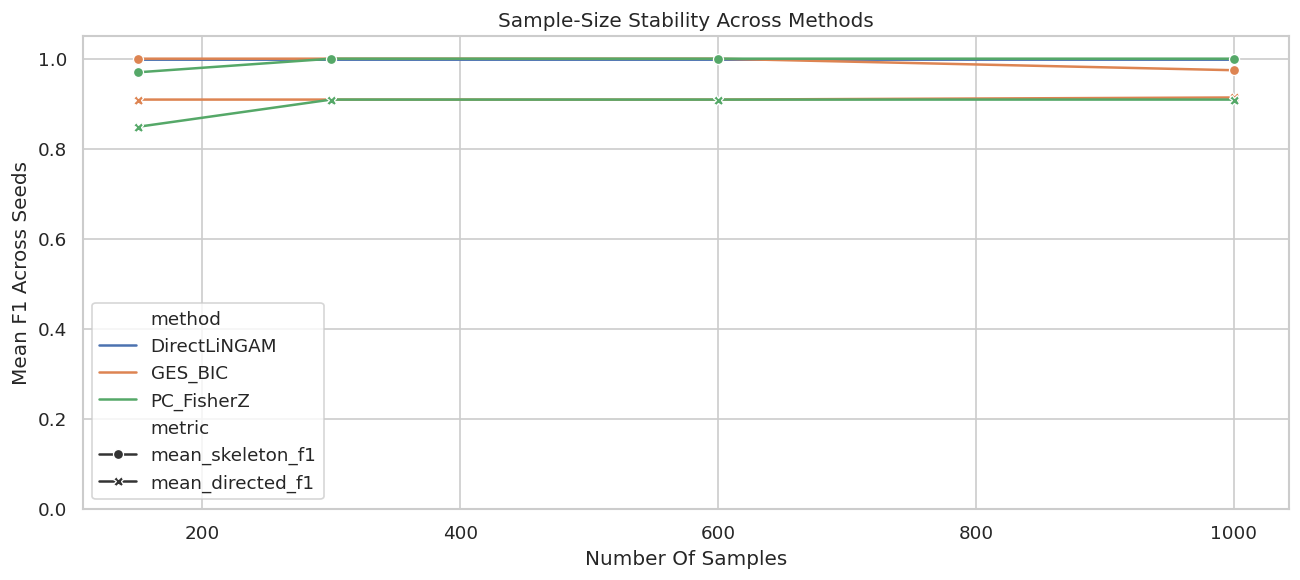

In [14]:
sample_plot = sample_seed_summary.melt(
    id_vars=["method", "n_samples"],
    value_vars=["mean_skeleton_f1", "mean_directed_f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=sample_plot, x="n_samples", y="score", hue="method", style="metric", markers=True, dashes=False, ax=ax)
ax.set_title("Sample-Size Stability Across Methods")
ax.set_xlabel("Number Of Samples")
ax.set_ylabel("Mean F1 Across Seeds")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_stability.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the practical sample-size story visible. If the directed score is unstable at small `n`, a report should avoid strong directional claims from that region.


#### Noise Sensitivity

Next we hold sample size fixed and vary the measurement noise scale. Higher noise weakens the signal-to-noise ratio and can make direct adjacencies harder to recover.


In [15]:
noise_metric_rows = []
for noise_scale in [0.60, 1.00, 1.40, 1.80]:
    sample_df = simulate_benchmark_data(n_samples=600, seed=RANDOM_SEED, noise_family="laplace", noise_scale=noise_scale)
    metrics, _ = run_benchmark_methods(sample_df, scenario=f"noise_{noise_scale:.2f}")
    metrics["noise_scale"] = noise_scale
    noise_metric_rows.append(metrics)
noise_sensitivity = pd.concat(noise_metric_rows, ignore_index=True)
noise_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_noise_sensitivity.csv", index=False)
display(noise_sensitivity[["method", "noise_scale", "skeleton_f1", "directed_f1", "extra_adjacencies", "missed_adjacencies", "reversed_true_edges"]].round(4))


,method,noise_scale,skeleton_f1,directed_f1,extra_adjacencies,missed_adjacencies,reversed_true_edges
0,PC_FisherZ,0.6,1.0,0.9091,0,0,0
1,GES_BIC,0.6,1.0,0.9091,0,0,0
2,DirectLiNGAM,0.6,1.0,1.0000,0,0,0
3,PC_FisherZ,1.0,1.0,0.9091,0,0,0
4,GES_BIC,1.0,1.0,0.9091,0,0,0
5,DirectLiNGAM,1.0,1.0,1.0000,0,0,0
6,PC_FisherZ,1.4,1.0,0.9091,0,0,0
7,GES_BIC,1.4,1.0,0.9091,0,0,0
8,DirectLiNGAM,1.4,1.0,1.0000,0,0,0
9,PC_FisherZ,1.8,1.0,0.9091,0,0,0


Noise sensitivity is a useful robustness check because real datasets rarely have the clean signal strength used in synthetic demos.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Plot Noise Sensitivity

The next figure tracks directed F1 as noise increases. Skeleton scores are saved in the table above; the directed score is usually the more fragile layer.


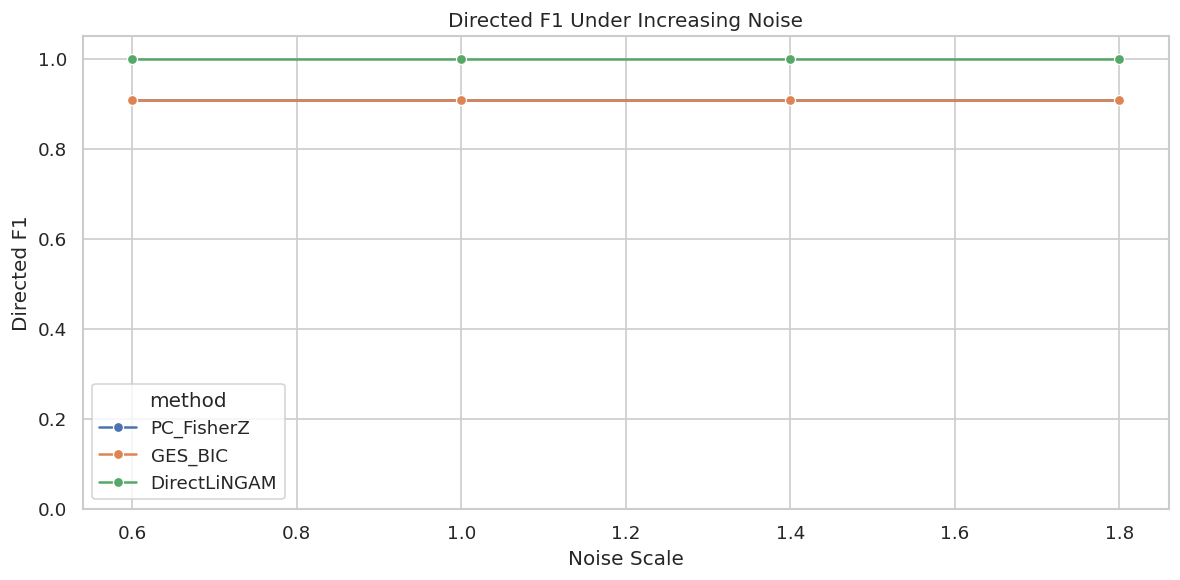

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=noise_sensitivity, x="noise_scale", y="directed_f1", hue="method", marker="o", ax=ax)
ax.set_title("Directed F1 Under Increasing Noise")
ax.set_xlabel("Noise Scale")
ax.set_ylabel("Directed F1")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_noise_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


If a method's directed score drops sharply as noise increases, its arrow claims should be reported with caution in low-signal applications.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Tuning Sensitivity: PC Alpha

PC depends on a conditional-independence significance level. Larger alpha values tend to remove fewer edges, while smaller values tend to remove more edges. The right value is data-dependent, so it should be scanned and reported.


In [17]:
pc_alpha_rows = []
for alpha in [0.001, 0.005, 0.01, 0.05, 0.10]:
    edges, elapsed = run_pc(baseline_df, alpha=alpha, label="PC_FisherZ")
    metrics = summarize_against_truth(edges, "PC_FisherZ", scenario=f"pc_alpha_{alpha}")
    metrics["alpha"] = alpha
    metrics["elapsed_seconds"] = elapsed
    pc_alpha_rows.append(metrics)
pc_alpha_sensitivity = pd.concat(pc_alpha_rows, ignore_index=True)
pc_alpha_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_alpha_sensitivity.csv", index=False)
display(pc_alpha_sensitivity[["alpha", "reported_edges", "skeleton_f1", "directed_f1", "extra_adjacencies", "missed_adjacencies"]].round(4))


,alpha,reported_edges,skeleton_f1,directed_f1,extra_adjacencies,missed_adjacencies
0,0.001,6,1.0,0.9091,0,0
1,0.005,6,1.0,0.9091,0,0
2,0.010,6,1.0,0.9091,0,0
3,0.050,6,1.0,0.9091,0,0
4,0.100,6,1.0,0.9091,0,0


The PC alpha scan shows whether the learned graph is stable across reasonable independence-test thresholds.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


### Tuning Sensitivity: GES Penalty

GES uses a score penalty. Larger penalties favor simpler graphs. Smaller penalties can admit extra edges. We scan the penalty multiplier used by the local BIC score.


In [18]:
ges_lambda_rows = []
for lambda_value in [0.25, 0.50, 1.00, 1.50, 2.00]:
    edges, elapsed = run_ges(baseline_df, lambda_value=lambda_value, label="GES_BIC")
    metrics = summarize_against_truth(edges, "GES_BIC", scenario=f"ges_lambda_{lambda_value}")
    metrics["lambda_value"] = lambda_value
    metrics["elapsed_seconds"] = elapsed
    ges_lambda_rows.append(metrics)
ges_lambda_sensitivity = pd.concat(ges_lambda_rows, ignore_index=True)
ges_lambda_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_ges_lambda_sensitivity.csv", index=False)
display(ges_lambda_sensitivity[["lambda_value", "reported_edges", "skeleton_f1", "directed_f1", "extra_adjacencies", "missed_adjacencies"]].round(4))


,lambda_value,reported_edges,skeleton_f1,directed_f1,extra_adjacencies,missed_adjacencies
0,0.25,8,0.8571,0.7143,2,0
1,0.50,7,0.9231,0.8333,1,0
2,1.00,6,1.0000,0.9091,0,0
3,1.50,6,1.0000,0.9091,0,0
4,2.00,6,1.0000,0.9091,0,0


The GES penalty scan makes the sparsity tradeoff explicit. A benchmark should say which penalty produced the reported graph.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


### Tuning Sensitivity: DirectLiNGAM Coefficient Threshold

DirectLiNGAM returns a weighted adjacency matrix. To report a graph, we need a coefficient threshold. The code below fits DirectLiNGAM once and scans several thresholds.


In [19]:
_, _, baseline_lingam_model = run_direct_lingam(baseline_df, threshold=0.12, label="DirectLiNGAM")
lingam_threshold_rows = []
lingam_threshold_edges = []
for threshold in [0.05, 0.08, 0.12, 0.16, 0.20]:
    edges = lingam_to_edge_table(baseline_lingam_model.adjacency_matrix_, label="DirectLiNGAM", threshold=threshold)
    metrics = summarize_against_truth(edges, "DirectLiNGAM", scenario=f"lingam_threshold_{threshold}")
    metrics["threshold"] = threshold
    lingam_threshold_rows.append(metrics)
    lingam_threshold_edges.append(edges.assign(threshold=threshold))
lingam_threshold_sensitivity = pd.concat(lingam_threshold_rows, ignore_index=True)
lingam_threshold_edge_table = pd.concat(lingam_threshold_edges, ignore_index=True)
lingam_threshold_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_threshold_sensitivity.csv", index=False)
lingam_threshold_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_threshold_edges.csv", index=False)
display(lingam_threshold_sensitivity[["threshold", "reported_edges", "skeleton_f1", "directed_f1", "extra_adjacencies", "missed_adjacencies"]].round(4))


,threshold,reported_edges,skeleton_f1,directed_f1,extra_adjacencies,missed_adjacencies
0,0.05,6,1.0,1.0,0,0
1,0.08,6,1.0,1.0,0,0
2,0.12,6,1.0,1.0,0,0
3,0.16,6,1.0,1.0,0,0
4,0.20,6,1.0,1.0,0,0


The threshold scan is a reminder that weighted-output algorithms still require a reporting rule. A low threshold can over-report weak edges; a high threshold can drop true but weaker effects.


#### Plot Tuning Sensitivity

This plot puts the main tuning scans on one page. Each panel uses the method-specific tuning parameter, so read the x-axis labels separately.


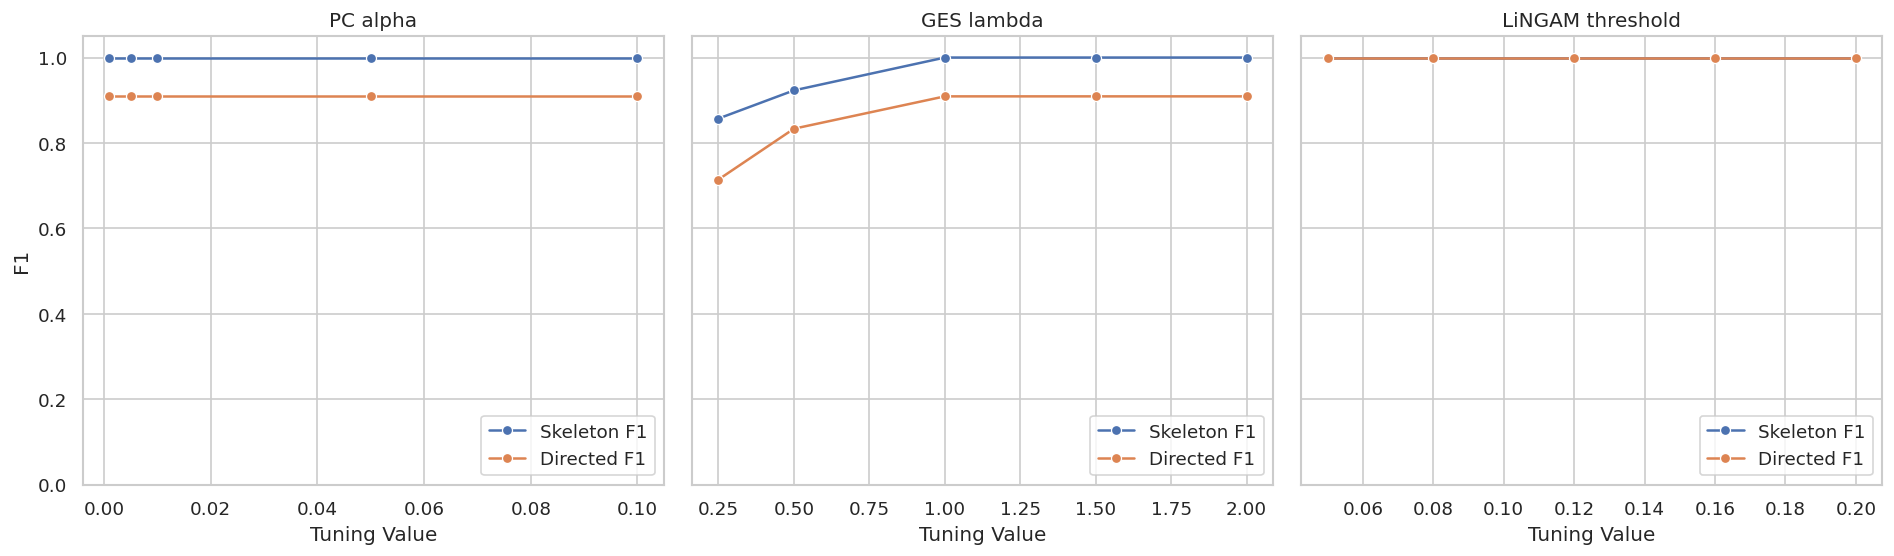

In [20]:
tuning_plot_frames = [
    pc_alpha_sensitivity.assign(tuning_family="PC alpha", tuning_value=pc_alpha_sensitivity["alpha"]),
    ges_lambda_sensitivity.assign(tuning_family="GES lambda", tuning_value=ges_lambda_sensitivity["lambda_value"]),
    lingam_threshold_sensitivity.assign(tuning_family="LiNGAM threshold", tuning_value=lingam_threshold_sensitivity["threshold"]),
]
tuning_plot = pd.concat(tuning_plot_frames, ignore_index=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, family in zip(axes, ["PC alpha", "GES lambda", "LiNGAM threshold"]):
    subset = tuning_plot[tuning_plot["tuning_family"] == family]
    sns.lineplot(data=subset, x="tuning_value", y="skeleton_f1", marker="o", label="Skeleton F1", ax=ax)
    sns.lineplot(data=subset, x="tuning_value", y="directed_f1", marker="o", label="Directed F1", ax=ax)
    ax.set_title(family)
    ax.set_xlabel("Tuning Value")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_tuning_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


Stable regions are more reassuring than isolated peaks. In an applied report, a graph chosen from a narrow peak should be described as sensitive to tuning.


### Assumption Stress Scenarios

The baseline was friendly. Now we deliberately perturb the assumptions:

- `linear_laplace`: baseline linear non-Gaussian data;
- `linear_gaussian`: directions are harder for LiNGAM because non-Gaussianity is removed;
- `nonlinear_laplace`: linear algorithms are misspecified;
- `hidden_confounding`: causal sufficiency is violated by an unobserved common cause.

The hidden-confounding scores are not a fair observed-DAG target; they are included to show how observed-DAG methods can become unstable when a key assumption fails.


In [21]:
stress_configs = [
    {"scenario": "linear_laplace", "noise_family": "laplace", "nonlinear": False, "hidden_strength": 0.0},
    {"scenario": "linear_gaussian", "noise_family": "gaussian", "nonlinear": False, "hidden_strength": 0.0},
    {"scenario": "nonlinear_laplace", "noise_family": "laplace", "nonlinear": True, "hidden_strength": 0.0},
    {"scenario": "hidden_confounding", "noise_family": "laplace", "nonlinear": False, "hidden_strength": 1.0},
]
stress_metric_rows = []
stress_edge_rows = []
for config in stress_configs:
    scenario_df = simulate_benchmark_data(
        n_samples=700,
        seed=3,
        noise_family=config["noise_family"],
        nonlinear=config["nonlinear"],
        hidden_strength=config["hidden_strength"],
    )
    scenario_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_{config['scenario']}.csv", index=False)
    metrics, edges = run_benchmark_methods(scenario_df, scenario=config["scenario"])
    metrics["noise_family"] = config["noise_family"]
    metrics["nonlinear"] = config["nonlinear"]
    metrics["hidden_strength"] = config["hidden_strength"]
    stress_metric_rows.append(metrics)
    stress_edge_rows.append(edges)
stress_metrics = pd.concat(stress_metric_rows, ignore_index=True)
stress_edges = pd.concat(stress_edge_rows, ignore_index=True)
stress_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_assumption_stress_metrics.csv", index=False)
stress_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_assumption_stress_edges.csv", index=False)
display(stress_metrics[["scenario", "method", "skeleton_f1", "directed_f1", "extra_adjacencies", "missed_adjacencies", "reversed_true_edges"]].round(4))


,scenario,method,skeleton_f1,directed_f1,extra_adjacencies,missed_adjacencies,reversed_true_edges
0,linear_laplace,PC_FisherZ,1.0000,0.9091,0,0,0
1,linear_laplace,GES_BIC,0.9231,0.9231,1,0,0
2,linear_laplace,DirectLiNGAM,1.0000,1.0000,0,0,0
3,linear_gaussian,PC_FisherZ,1.0000,0.9091,0,0,0
4,linear_gaussian,GES_BIC,1.0000,0.9091,0,0,0
5,linear_gaussian,DirectLiNGAM,0.8571,0.4286,2,0,3
6,nonlinear_laplace,PC_FisherZ,1.0000,0.9091,0,0,0
7,nonlinear_laplace,GES_BIC,1.0000,0.9091,0,0,0
8,nonlinear_laplace,DirectLiNGAM,0.9231,0.7692,1,0,1
9,hidden_confounding,PC_FisherZ,0.8000,0.3636,3,0,1


The stress table shows which failures are algorithm-specific and which are assumption-level. Gaussian noise mainly weakens DirectLiNGAM direction recovery; hidden confounding can create extra adjacencies or misleading directions for observed-DAG methods.


#### Plot Assumption Stress Results

The next figure compares directed F1 across the stress scenarios. Skeleton details are saved in the table above.


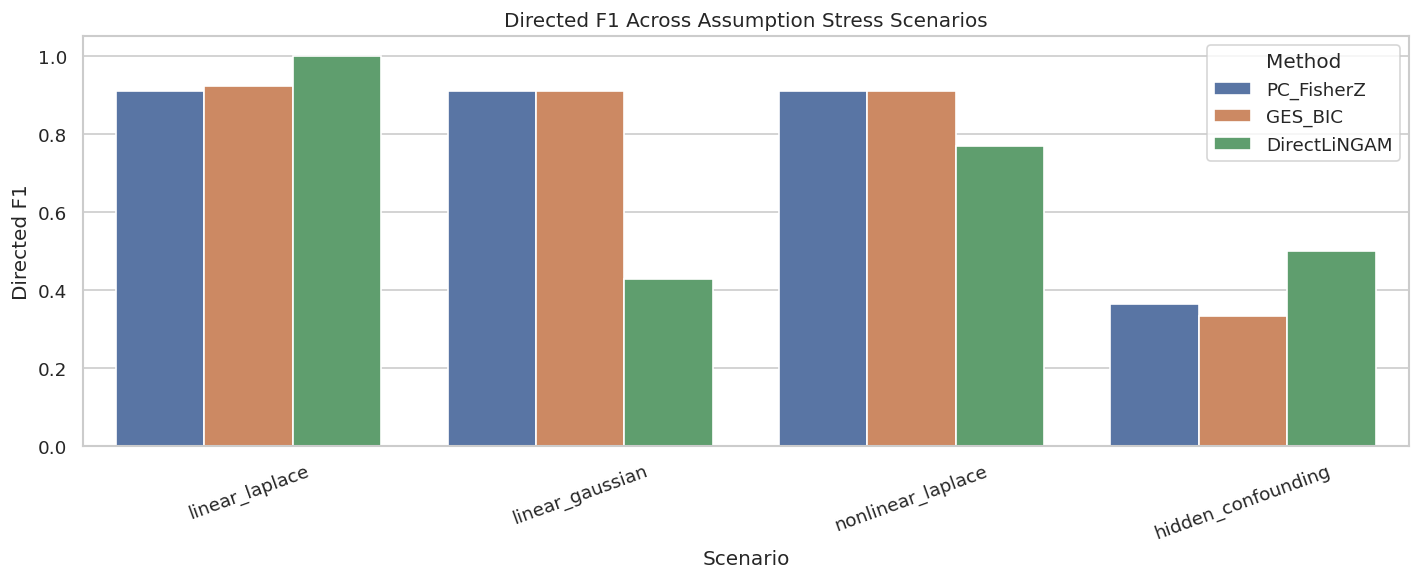

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=stress_metrics, x="scenario", y="directed_f1", hue="method", ax=ax)
ax.set_title("Directed F1 Across Assumption Stress Scenarios")
ax.set_xlabel("Scenario")
ax.set_ylabel("Directed F1")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Method")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_assumption_stress_directed_f1.png", dpi=160, bbox_inches="tight")
plt.show()


The plot turns the warning into something visible. A method that performs beautifully under one data-generating regime can become much less reliable under another.


#### Targeted Hidden-Confounding Check with FCI

FCI is designed for settings where hidden common causes may exist. The code below runs FCI only on the hidden-confounding scenario. Since the target graph type is different from the observed DAG, we inspect whether the output marks possible hidden structure.


In [23]:
hidden_df = pd.read_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding.csv")
fci_edges, fci_elapsed = run_fci(hidden_df, alpha=0.01, label="FCI_FisherZ_hidden")
fci_edges["elapsed_seconds"] = fci_elapsed
fci_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_fci_edges.csv", index=False)
display(fci_edges)
print(f"FCI elapsed seconds: {fci_elapsed:.4f}")


renewal --> support


,run,source,edge_type,target,elapsed_seconds
0,FCI_FisherZ_hidden,need,o-o,intent,0.020657
1,FCI_FisherZ_hidden,need,o-o,match,0.020657
2,FCI_FisherZ_hidden,need,o->,renewal,0.020657
3,FCI_FisherZ_hidden,intent,o-o,match,0.020657
4,FCI_FisherZ_hidden,intent,o->,renewal,0.020657
5,FCI_FisherZ_hidden,match,o-o,engagement,0.020657
6,FCI_FisherZ_hidden,engagement,-->,support,0.020657
7,FCI_FisherZ_hidden,engagement,-->,renewal,0.020657
8,FCI_FisherZ_hidden,renewal,-->,support,0.020657


FCI elapsed seconds: 0.0207


FCI uses endpoint marks that should be read differently from a DAG. Bidirected or partially marked edges are signs that hidden structure may be involved, not ordinary directed arrows from the observed DAG benchmark.


#### Edge Stability Signatures

Stability can also be summarized by graph signatures. The next step counts how many unique graphs each method produced across the sample-size and seed grid.


In [24]:
# Define reusable helpers for the Edge Stability Signatures section.
def edge_signature(edge_df):
    """
    Idea: Create a stable text signature for a graph edge so edge sets can be compared.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    str
        Stable text signature for the set of learned graph edges.
    """
    if edge_df.empty:
        return "empty"
    return " | ".join(sorted(f"{row.source} {row.edge_type} {row.target}" for row in edge_df.itertuples(index=False)))
signature_rows = []
for (method, n_samples, seed), group in sample_seed_edges.groupby(["run", "n_samples", "seed"]):
    signature_rows.append(
        {
            "method": method,
            "n_samples": n_samples,
            "seed": seed,
            "edge_signature": edge_signature(group),
            "reported_edges": len(group),
        }
    )
signature_table = pd.DataFrame(signature_rows)
signature_summary = signature_table.groupby(["method", "n_samples"], as_index=False).agg(
    unique_graphs=("edge_signature", "nunique"),
    min_reported_edges=("reported_edges", "min"),
    max_reported_edges=("reported_edges", "max"),
)
signature_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_edge_signatures.csv", index=False)
signature_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_edge_signature_summary.csv", index=False)
display(signature_summary)


,method,n_samples,unique_graphs,min_reported_edges,max_reported_edges
0,DirectLiNGAM,150,1,6,6
1,DirectLiNGAM,300,1,6,6
2,DirectLiNGAM,600,1,6,6
3,DirectLiNGAM,1000,1,6,6
4,GES_BIC,150,1,6,6
5,GES_BIC,300,1,6,6
6,GES_BIC,600,1,6,6
7,GES_BIC,1000,2,6,7
8,PC_FisherZ,150,2,5,6
9,PC_FisherZ,300,1,6,6


Unique graph counts help distinguish stable metrics from stable graphs. Two graphs can have the same F1 score but disagree about which specific edge changed.





## Reporting and Takeaways

### Runtime Summary

Runtime is part of method selection. A method that is statistically attractive but too slow for repeated sensitivity checks may be hard to use responsibly on a larger graph.


In [25]:
runtime_summary = pd.concat(
    [
        baseline_metrics.assign(source_table="baseline"),
        sample_seed_metrics.assign(source_table="sample_seed"),
        noise_sensitivity.assign(source_table="noise"),
        stress_metrics.assign(source_table="stress"),
    ],
    ignore_index=True,
).groupby("method", as_index=False).agg(
    runs=("elapsed_seconds", "count"),
    median_elapsed_seconds=("elapsed_seconds", "median"),
    max_elapsed_seconds=("elapsed_seconds", "max"),
)
runtime_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_runtime_summary.csv", index=False)
display(runtime_summary.round(4))


,method,runs,median_elapsed_seconds,max_elapsed_seconds
0,DirectLiNGAM,21,0.0235,0.0255
1,GES_BIC,21,0.0131,0.0234
2,PC_FisherZ,21,0.0080,0.0132


The runtime table is small here because the graph has only six variables. On wider graphs, runtime and stability checks become a much bigger part of practical method choice.


### Benchmark Reporting Checklist

A benchmark should make its assumptions and fragility visible. This checklist is a reusable template for reporting causal discovery comparisons.


| item | what_to_report | why_it_matters |
| --- | --- | --- |
| Graph target | Whether metrics target a DAG, CPDAG, PAG, skeleton, or weighted adjacency matrix. | Different algorithms return different graph objects and should not be collapsed casually. |
| Data-generating assumptions | Linearity, noise family, causal sufficiency, stationarity, and sample size. | Benchmark performance only applies to the assumptions actually tested. |
| Skeleton and direction metrics | Report adjacency recovery separately from arrow-direction recovery. | Partially directed graphs can have correct adjacencies but unresolved directions. |
| Tuning settings | PC alpha, GES penalty, coefficient threshold, and any prior knowledge used. | Graph output can change materially across tuning choices. |
| Stability checks | Seed, sample-size, noise, resampling, and graph-signature stability. | A single graph can hide high variance across plausible datasets. |
| Assumption stress tests | Nonlinearity, Gaussian noise, hidden confounding, missingness, or selection stress. | Failure modes are often more informative than the clean baseline result. |
| Claim strength | Whether learned edges are final claims, candidate hypotheses, or diagnostic signals. | Causal discovery rarely justifies strong claims without domain and design support. |


The checklist is conservative. Good benchmarking does not make a graph automatically true; it makes the graph's support and fragility easier to inspect.


## Summary


The lesson leaves us with a practical benchmark pattern: start from a known graph, compare methods by graph layer, scan tuning settings, test stability, then stress the assumptions before making any causal claim from a discovered graph.
